# Анализ возвратов по номенклатуре

Дополнительный разбор к главе 4: какие товарные позиции формируют общий процент возвратов (15,6% от валовых продаж по 1С), и как этот показатель различается по товарным группам.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE = Path("..").resolve()
DATA = BASE / "Данные" / "Итоговые таблицы"
IMG_DIR = Path("img")
IMG_DIR.mkdir(exist_ok=True)

sales_by_counterparties = pd.read_parquet(DATA / "sales_by_counterparties.parquet")

formatter = mticker.FuncFormatter(lambda value, _: f"{value:,.0f}".replace(",", " "))

## Базовый разрез продаж по номенклатуре

In [2]:
sales_start_date = "2025-06-01"
sales_end_date = "2026-06-30"

sales_period = sales_by_counterparties[
    sales_by_counterparties["sale_date"].between(sales_start_date, sales_end_date)
    & sales_by_counterparties["sales_doc_type"].eq("Реализация")
].copy()

sales_by_item = (
    sales_period.groupby("nomenclature")
    .agg(продали=("amount", "sum"), кол=("quantity", "sum"), документов=("sales_doc_raw", "nunique"))
    .reset_index()
    .sort_values("продали", ascending=False)
)
sales_by_item["доля_в_продажах"] = sales_by_item["продали"].div(sales_by_item["продали"].sum()).mul(100)

display(sales_by_item)
print("Итого продали:", sales_by_item["продали"].sum())

,nomenclature,продали,кол,документов,доля_в_продажах
6,"Изделия хлебобулочные маффин ""Каприз"" с изюмом...",15515130.00,71744.0,385,29.693938
4,"Изделия хлебобулочные ""ЭТЮД "" с ванильной начи...",11528805.00,44904.0,645,22.064631
0,"Изделия хлебобулочные ""Кокетка "" с ванильной н...",7355750.00,29423.0,419,14.077948
8,"Изделия хлебобулочные""Мадлены "" ассорти с начи...",5990239.20,29589.0,170,11.464538
3,"Изделия хлебобулочные ""Улыбка "" песочное 1,0 кг",4008716.64,20899.0,120,7.672162
1,"Изделия хлебобулочные ""МАЭСТРО"" песочное 1,0 кг",2427381.10,12729.0,96,4.645691
10,"Сдобное хлебобулочное изделие ""ДИВНОЕ""с начинк...",2381872.00,11390.0,79,4.558593
2,"Изделия хлебобулочные ""НЕЖЕНКА"" с ванильной на...",1097720.00,4222.0,63,2.100893
11,"Хлебобулочное изделие бисквитное ""Мадлены""с из...",703345.00,3295.0,35,1.346111
9,"Пирожное слоеное ""Сувенир"" 1,0 кг",562750.00,2251.0,43,1.077030


Итого продали: 52250158.940000005


In [3]:
item_to_type = {
    "Каприз": "Кекс с изюмом",
    "Мадлены": "Кекс с изюмом",
    "Дивное": "Песочное печенье",
    "Этюд": "Ажурная коса",
    "Кокетка": "Ажурная коса",
    "Улыбка": "Песочное печенье",
}

sales_period["товар"] = pd.NA
for short_name in item_to_type:
    mask = sales_period["nomenclature"].str.contains(short_name, case=False, na=False)
    sales_period.loc[mask, "товар"] = short_name
sales_period["тип"] = sales_period["товар"].map(item_to_type)

mapped_sales = sales_period[sales_period["товар"].notna()].copy()

sales_by_type = (
    mapped_sales.groupby("тип")["amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"amount": "продали"})
)
sales_by_type["доля"] = sales_by_type["продали"].div(sales_by_type["продали"].sum()).mul(100)

display(sales_by_type)
print("Покрытие маппингом:", mapped_sales["amount"].sum(), "из", sales_period["amount"].sum())

,тип,продали,доля
0,Кекс с изюмом,22208714.20,46.493738
1,Ажурная коса,19167805.00,40.127623
2,Песочное печенье,6390588.64,13.378638


Покрытие маппингом: 47767107.84 из 52250158.94


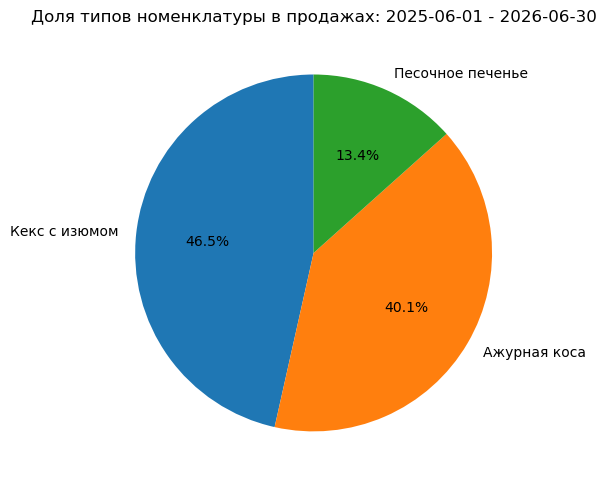

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    sales_by_type["продали"],
    labels=sales_by_type["тип"],
    autopct="%1.1f%%",
    startangle=90,
)
ax.set_title(f"Доля типов номенклатуры в продажах: {sales_start_date} - {sales_end_date}")
plt.tight_layout()
plt.savefig(IMG_DIR / "sales_share_by_type.png", dpi=150)
plt.show()

## Возвраты по номенклатуре (топ позиций)

In [5]:
start_date = "2025-06-01"
end_date = "2026-06-30"

period = sales_by_counterparties[
    sales_by_counterparties["sale_date"].between(start_date, end_date)
    & sales_by_counterparties["sales_doc_type"].isin(["Реализация", "Корректировка реализации"])
].copy()

period["продали"] = period["amount"].where(period["sales_doc_type"].eq("Реализация"), 0)
period["вернули"] = (-period["amount"]).where(period["sales_doc_type"].eq("Корректировка реализации"), 0)
period["кол_продали"] = period["quantity"].where(period["sales_doc_type"].eq("Реализация"), 0)
period["кол_вернули"] = (-period["quantity"]).where(period["sales_doc_type"].eq("Корректировка реализации"), 0)

by_item = (
    period.groupby("nomenclature")
    .agg(
        продали=("продали", "sum"),
        вернули=("вернули", "sum"),
        кол_продали=("кол_продали", "sum"),
        кол_вернули=("кол_вернули", "sum"),
        документов=("sales_doc_raw", "nunique"),
    )
    .reset_index()
)
by_item["нетто"] = by_item["продали"] - by_item["вернули"]
by_item["% возврата суммы"] = by_item["вернули"].div(by_item["продали"].replace(0, pd.NA)).mul(100)
by_item["% возврата количества"] = by_item["кол_вернули"].div(by_item["кол_продали"].replace(0, pd.NA)).mul(100)
by_item = by_item[by_item["продали"] > 0].sort_values("вернули", ascending=False)

display(by_item)

,nomenclature,продали,вернули,кол_продали,кол_вернули,документов,нетто,% возврата суммы,% возврата количества
8,"Изделия хлебобулочные маффин ""Каприз"" с изюмом...",15515130.00,3302480.50,71744.0,15452.0,626,12212649.50,21.285548,21.53769
10,"Изделия хлебобулочные""Мадлены "" ассорти с начи...",5990239.20,1148997.70,29589.0,5636.0,270,4841241.50,19.181166,19.047619
12,"Сдобное хлебобулочное изделие ""ДИВНОЕ""с начинк...",2381872.00,599957.00,11390.0,2849.0,145,1781915.00,25.188465,25.013169
4,"Изделия хлебобулочные ""Улыбка "" песочное 1,0 кг",4008716.64,392801.40,20899.0,2036.0,172,3615915.24,9.798682,9.742093
0,"Изделия хлебобулочные ""Кокетка "" с ванильной н...",7355750.00,294250.00,29423.0,1177.0,504,7061500.00,4.000272,4.000272
5,"Изделия хлебобулочные ""ЭТЮД "" с ванильной начи...",11528805.00,286630.00,44904.0,1120.0,739,11242175.00,2.486207,2.49421
1,"Изделия хлебобулочные ""МАЭСТРО"" песочное 1,0 кг",2427381.10,281054.76,12729.0,1454.0,161,2146326.34,11.578518,11.422735
14,"Хлебобулочное изделие бисквитное ""Мадлены""с из...",703345.00,163820.00,3295.0,769.0,65,539525.00,23.291557,23.338392
3,"Изделия хлебобулочные ""НЕЖЕНКА"" с ванильной на...",1097720.00,120640.00,4222.0,464.0,93,977080.00,10.990052,10.990052
11,"Пирожное слоеное ""Сувенир"" 1,0 кг",562750.00,43250.00,2251.0,173.0,68,519500.00,7.685473,7.685473


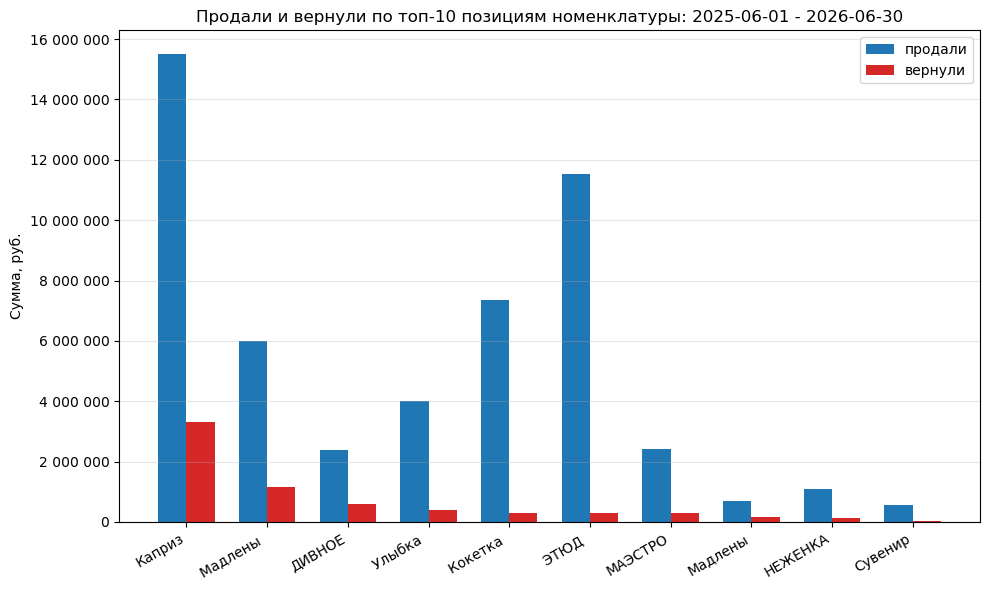

In [6]:
top_items = by_item.head(10).copy()
top_items["короткое_название"] = top_items["nomenclature"].str.extract(r'"([^"]+)"')

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(top_items))
width = 0.35
ax.bar([i - width / 2 for i in x], top_items["продали"], width=width, label="продали", color="#1f77b4")
ax.bar([i + width / 2 for i in x], top_items["вернули"], width=width, label="вернули", color="#d62728")
ax.set_xticks(list(x))
ax.set_xticklabels(top_items["короткое_название"], rotation=30, ha="right")
ax.set_ylabel("Сумма, руб.")
ax.yaxis.set_major_formatter(formatter)
ax.set_title(f"Продали и вернули по топ-10 позициям номенклатуры: {start_date} - {end_date}")
ax.grid(True, alpha=0.3, axis="y")
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "returns_top_items.png", dpi=150)
plt.show()

## Агрегация по товарным группам

Сопоставление пар похожих изделий (Каприз/Мадлены - кекс с изюмом; Этюд/Кокетка - ажурная коса; Дивное/Улыбка - песочное печенье).

In [7]:
item_to_type = {
    "Каприз": "Кекс с изюмом",
    "Мадлены": "Кекс с изюмом",
    "Дивное": "Песочное печенье",
    "Этюд": "Ажурная коса",
    "Кокетка": "Ажурная коса",
    "Улыбка": "Песочное печенье",
}

type_period = period.copy()
type_period["товар"] = pd.NA
for short_name in item_to_type:
    mask = type_period["nomenclature"].str.contains(short_name, case=False, na=False)
    type_period.loc[mask, "товар"] = short_name
type_period["тип"] = type_period["товар"].map(item_to_type)
type_period = type_period[type_period["товар"].notna()].copy()

type_totals = (
    type_period.groupby("тип")
    .agg(продали=("продали", "sum"), вернули=("вернули", "sum"))
    .reset_index()
)
type_totals["нетто"] = type_totals["продали"] - type_totals["вернули"]
type_totals["% возврата"] = type_totals["вернули"].div(type_totals["продали"]).mul(100)
type_totals = type_totals.sort_values("продали", ascending=False)

display(type_totals)

,тип,продали,вернули,нетто,% возврата
1,Кекс с изюмом,22208714.20,4714098.2,17494616.00,21.226345
0,Ажурная коса,19167805.00,580880.0,18586925.00,3.030498
2,Песочное печенье,6390588.64,992758.4,5397830.24,15.534694


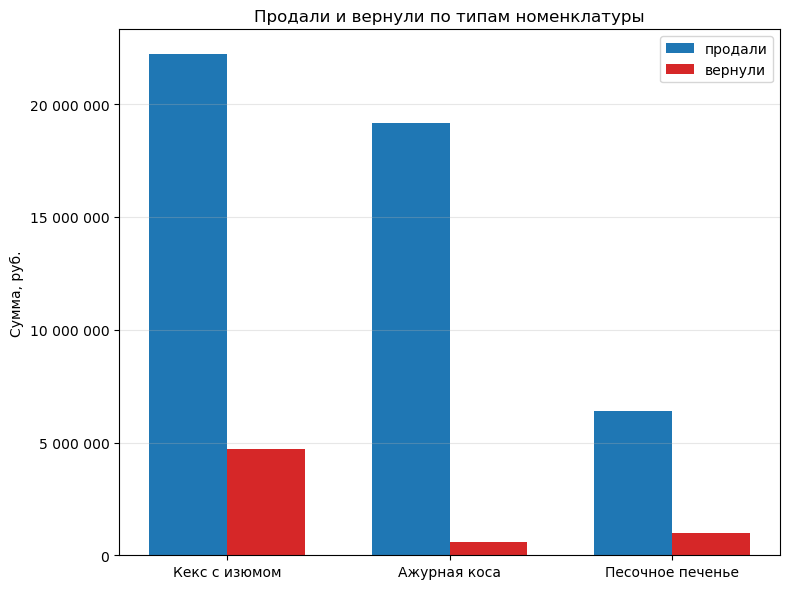

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
x = range(len(type_totals))
width = 0.35
ax.bar([i - width / 2 for i in x], type_totals["продали"], width=width, label="продали", color="#1f77b4")
ax.bar([i + width / 2 for i in x], type_totals["вернули"], width=width, label="вернули", color="#d62728")
ax.set_xticks(list(x))
ax.set_xticklabels(type_totals["тип"])
ax.set_ylabel("Сумма, руб.")
ax.yaxis.set_major_formatter(formatter)
ax.set_title("Продали и вернули по типам номенклатуры")
ax.grid(True, alpha=0.3, axis="y")
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "returns_by_type.png", dpi=150)
plt.show()